# The "Airy" Secretary Problem
### or: derangements, and why the chance of perfect chaos is $1/e$

A classic from B. V. Gnedenko's *Theory of Probability*:

> An absent-minded secretary has $n$ letters and $n$ addressed envelopes. She puts the letters
> into the envelopes completely at random. What is the probability that **no** letter ends up
> in the correct envelope?

This notebook: the exact answer (inclusion–exclusion), the beautiful limit $\to 1/e$, and a simulation to watch it happen.

## 1. The exact answer: derangements

A permutation with no fixed points is called a **derangement**; the count is denoted $!n$ ("subfactorial").

Let $A_i$ = "letter $i$ lands in envelope $i$". We want $P(\bar{A}_1 \cap \cdots \cap \bar{A}_n)$.
By inclusion–exclusion:

$$P(\text{no match}) = \sum_{k=0}^{n} \frac{(-1)^k}{k!}$$

(each $k$-fold intersection has probability $(n-k)!/n! = 1/[n(n-1)\cdots(n-k+1)]$, and there are $\binom{n}{k}$ of them.)

The $n!$ cancels neatly: the number of derangements is $!n = n!\sum_{k=0}^{n}(-1)^k/k!$.

## 2. The punchline: the limit is $1/e$

As $n \to \infty$:

$$\sum_{k=0}^{n} \frac{(-1)^k}{k!} \longrightarrow \sum_{k=0}^{\infty} \frac{(-1)^k}{k!} = e^{-1} = \frac{1}{e} \approx 0.3679$$

That's the partial-sum expansion of $e^{-1}$. So for even a handful of envelopes, the chance the
secretary gets *every single one* wrong is about **37%** — a number that essentially stops changing as $n$ grows.

In [1]:
import math
exact = lambda n: sum(((-1) ** k) / math.factorial(k) for k in range(n + 1))
for n in [1, 2, 3, 4, 5, 6, 7, 8, 10, 20, 50]:
    print(f"n={n:>3d}  P(no match) = {exact(n):.6f}")
print(f"\n1/e = {math.exp(-1):.6f}")

n=  1  P(no match) = 0.000000
n=  2  P(no match) = 0.500000
n=  3  P(no match) = 0.333333
n=  4  P(no match) = 0.375000
n=  5  P(no match) = 0.366667
n=  6  P(no match) = 0.368056
n=  7  P(no match) = 0.367857
n=  8  P(no match) = 0.367882
n= 10  P(no match) = 0.367879
n= 20  P(no match) = 0.367879
n= 50  P(no match) = 0.367879

1/e = 0.367879


## 3. Simulation: random permutations

Simulate the secretary: shuffle $n$ letters $m$ times, count trials with no letter in the right envelope.

In [2]:
import numpy as np

def simulate(n, trials=20000, seed=42):
    rng = np.random.default_rng(seed)
    perms = np.argsort(rng.random((trials, n)), axis=1)   # random permutations
    correct = (perms == np.arange(n))                     # where letter i hit envelope i
    return (~correct.any(axis=1)).mean()

for n in [3, 5, 10, 30, 100]:
    print(f"n={n:>4d}  simulated P(no match) = {simulate(n):.4f}   (exact {exact(n):.4f})")

n=   3  simulated P(no match) = 0.3337   (exact 0.3333)
n=   5  simulated P(no match) = 0.3618   (exact 0.3667)
n=  10  simulated P(no match) = 0.3650   (exact 0.3679)
n=  30  simulated P(no match) = 0.3703   (exact 0.3679)


n= 100  simulated P(no match) = 0.3700   (exact 0.3679)


## 4. Watching the convergence

Plot exact $P_n$ against $1/e$ as $n$ grows.

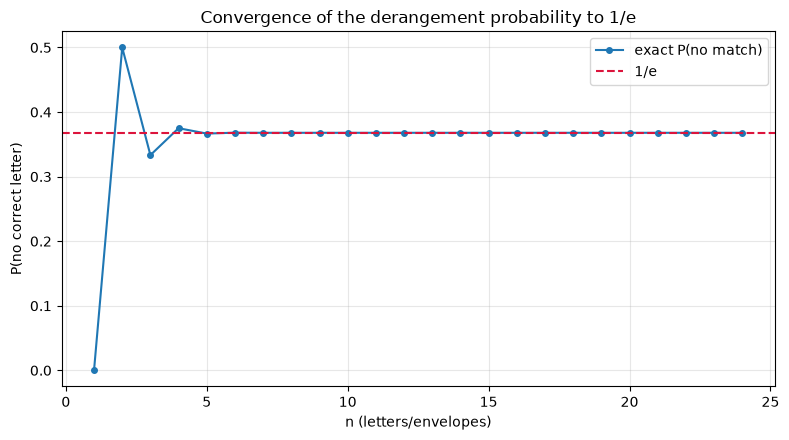

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

ns = range(1, 25)
probs = [exact(n) for n in ns]

plt.figure(figsize=(8, 4.5))
plt.plot(list(ns), probs, 'o-', ms=4, label='exact P(no match)')
plt.axhline(math.exp(-1), color='crimson', ls='--', label='1/e')
plt.xlabel('n (letters/envelopes)')
plt.ylabel('P(no correct letter)')
plt.title('Convergence of the derangement probability to 1/e')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 5. Takeaways

- The inclusion–exclusion formula gives a clean alternating series — no recursion needed.
- By $n=7$ the probability is already $0.3679$, matching $1/e$ to four decimals.
- Simulation confirms theory — the secretary is doomed to perfection-by-accident ~37% of the time, no matter how much mail there is.

*Reference: B. V. Gnedenko, Theory of Probability, Ch. 1 — problems on the "airy" (absent-minded) secretary.*